Objetivo del notebook:
Población analizada:
Periodo:
Variables generadas:
Tablas/figuras que alimenta:
Limitaciones:

# 01 - Exploración General
**Fecha:** 20 abril 2026  
**Datos:** octubre 2025 - febrero 2026  
**Objetivo:** Primera visión general de usuarios, ingresos y costes de IA

## Hallazgos clave
- 32.636 usuarios totales | 1.58% tasa de conversión
- Perfil: 75% mujeres, 99.9% universitarios
- Ingresos acumulados: 5.010€ | Coste IA acumulado: ~578$
- Enero 2026: explosión de 25.134 registros (77% de toda la base)
- 51.7% de usuarios de enero son "turistas" (XP < 100)
- Usuarios de pago tienen 6-8x más XP que usuarios free
- Churn enero: 10.3% volvieron a free tras pagar

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Cambia esto a tu ruta real
DATA_PATH = "../data/"

# Para que los gráficos se vean bien
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style="whitegrid")

In [3]:
users = pd.read_csv(DATA_PATH + "users.csv")
subs = pd.read_csv(DATA_PATH + "stripe_subscriptions.csv")
charges = pd.read_csv(DATA_PATH + "stripe_charges.csv")
test_sessions = pd.read_csv(DATA_PATH + "test_sessions.csv")
ai_spans = pd.read_csv(DATA_PATH + "ai_spans.csv", low_memory=False)
traces = pd.read_csv(DATA_PATH + "traces.csv")

print("✅ Archivos cargados correctamente")

✅ Archivos cargados correctamente


In [4]:
tablas = {
    "users": users,
    "stripe_subscriptions": subs,
    "stripe_charges": charges,
    "test_sessions": test_sessions,
    "ai_spans": ai_spans,
    "traces": traces
}

for nombre, df in tablas.items():
    print(f"\n{'='*40}")
    print(f"📄 {nombre}")
    print(f"   Filas: {len(df):,} | Columnas: {df.shape[1]}")
    print(f"   Columnas: {list(df.columns)}")


📄 users
   Filas: 32,636 | Columnas: 32
   Columnas: ['id', 'type', 'gender', 'birth_date_range', 'study_id', 'created_at', 'is_verified', 'referral_code', 'referred_by', 'actual_streak', 'best_streak', 'level', 'xp', 'proxus_coins', 'last_activity_date', 'daily_xp_earned', 'daily_pc_earned', 'daily_reset_date', 'extra_questions', 'extra_chat_magia', 'extra_chat_supermagia', 'extra_flashcards', 'is_beta_tester', 'stripe_customer_id', 'subscription_type', 'subscription_period', 'subscription_created_at', 'marketing_consent', 'fsrs_weights', 'last_optimization', 'is_ambassador', 'ugc_creator_started_at']

📄 stripe_subscriptions
   Filas: 627 | Columnas: 32
   Columnas: ['id', 'customer', 'status', 'currency', 'created', 'current_period_start', 'current_period_end', 'start_date', 'ended_at', 'cancel_at', 'canceled_at', 'cancel_at_period_end', 'cancellation_reason', 'cancellation_feedback', 'trial_start', 'trial_end', 'price_id', 'price_amount', 'price_currency', 'price_interval', 'price_

In [5]:
print("=== USUARIOS ===")
print(f"Total usuarios: {len(users):,}")
print(f"\nPlan de suscripción:")
print(users['subscription_type'].value_counts())
print(f"\nTipo de usuario:")
print(users['type'].value_counts())
print(f"\nGénero:")
print(users['gender'].value_counts())

=== USUARIOS ===
Total usuarios: 32,636

Plan de suscripción:
subscription_type
free          32120
magia           399
supermagia      117
Name: count, dtype: int64

Tipo de usuario:
type
university    32601
opposition       35
Name: count, dtype: int64

Género:
gender
female                     24559
male                        7059
prefer_not_to_say            604
other                        329
other/prefer not to say       85
Name: count, dtype: int64


In [6]:
total_users = len(users)
paying_users = len(users[users['subscription_type'] != 'free'])
users_with_stripe = users['stripe_customer_id'].notna().sum()

print("=== CONVERSIÓN ===")
print(f"Total usuarios: {total_users:,}")
print(f"Usuarios con Stripe: {users_with_stripe:,}")
print(f"Usuarios de pago actualmente: {paying_users:,}")
print(f"Tasa de conversión actual: {paying_users/total_users*100:.2f}%")

=== CONVERSIÓN ===
Total usuarios: 32,636
Usuarios con Stripe: 619
Usuarios de pago actualmente: 516
Tasa de conversión actual: 1.58%


In [7]:
print("=== SUSCRIPCIONES STRIPE ===")
print(subs['status'].value_counts())
print(f"\nPlanes contratados (por precio):")
print(subs['price_amount'].value_counts())

=== SUSCRIPCIONES STRIPE ===
status
active      492
canceled    108
trialing     20
past_due      7
Name: count, dtype: int64

Planes contratados (por precio):
price_amount
699     436
1299    133
1699     35
3199     23
Name: count, dtype: int64


In [8]:
ingresos = charges[charges['status'] == 'succeeded']['amount'].sum() / 100
fallidos = charges[charges['status'] == 'failed']['amount'].sum() / 100

print("=== INGRESOS ===")
print(f"Ingresos totales cobrados: {ingresos:,.2f} EUR")
print(f"Cobros fallidos: {fallidos:,.2f} EUR")
print(f"Número de cobros exitosos: {len(charges[charges['status'] == 'succeeded']):,}")
print(f"Número de cobros fallidos: {len(charges[charges['status'] == 'failed']):,}")

=== INGRESOS ===
Ingresos totales cobrados: 5,010.84 EUR
Cobros fallidos: 714.15 EUR
Número de cobros exitosos: 618
Número de cobros fallidos: 85


In [9]:
print("=== COSTES DE IA ===")
coste_total = ai_spans['cost'].sum()
print(f"Coste total de IA: ${coste_total:,.2f}")
print(f"\nCoste por tipo de modelo:")
print(ai_spans.groupby('model_mask')['cost'].sum().round(4))
print(f"\nCoste por funcionalidad (top 10):")
print(traces.merge(ai_spans, left_on='id', right_on='trace_id')
      .groupby('related_object_type')['cost']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .round(4))

=== COSTES DE IA ===
Coste total de IA: $578.77

Coste por tipo de modelo:
model_mask
magia        51.77
supermagia   17.32
Name: cost, dtype: float64

Coste por funcionalidad (top 10):
related_object_type
test_from_notes           311.37
flashcards_new            106.52
chat_conversation          70.92
test_similar_to_exams      48.68
test_extract_from_exams    28.34
flashcards                 12.44
similar_to_exams            0.24
from_notes                  0.22
extract_from_exams          0.04
Name: cost, dtype: float64


In [13]:
# Investigar qué valores raros hay en created_at
print("Primeros 5 valores:")
print(users['created_at'].head())
print("\nTipos de datos únicos en la columna:")
print(users['created_at'].dtype)
print("\nAlgún valor nulo?")
print(users['created_at'].isna().sum())

Primeros 5 valores:
0    "2025-11-10T07:04:50.103Z"
1    "2026-01-12T15:25:09.628Z"
2    "2025-11-13T15:28:49.954Z"
3    "2025-11-15T11:23:47.688Z"
4    "2025-12-09T15:05:19.170Z"
Name: created_at, dtype: object

Tipos de datos únicos en la columna:
object

Algún valor nulo?
0


In [14]:
# Ver el rango temporal de los datos
print("=== RANGO TEMPORAL ===")

# Función para limpiar y convertir fechas con comillas
def parse_dates(series):
    return pd.to_datetime(series.str.strip('"'), utc=True)

users['created_at'] = parse_dates(users['created_at'])
print(f"Usuarios - desde: {users['created_at'].min()} hasta: {users['created_at'].max()}")

test_sessions['created_at'] = parse_dates(test_sessions['created_at'])
print(f"Test sessions - desde: {test_sessions['created_at'].min()} hasta: {test_sessions['created_at'].max()}")

ai_spans['created_at'] = parse_dates(ai_spans['created_at'])
print(f"AI spans - desde: {ai_spans['created_at'].min()} hasta: {ai_spans['created_at'].max()}")

subs['created'] = parse_dates(subs['created'])
print(f"Suscripciones - desde: {subs['created'].min()} hasta: {subs['created'].max()}")

=== RANGO TEMPORAL ===
Usuarios - desde: 2025-05-11 15:57:02.022000+00:00 hasta: 2026-02-07 21:03:18.057000+00:00
Test sessions - desde: 2025-05-11 21:13:46+00:00 hasta: 2026-02-07 22:10:33.584000+00:00
AI spans - desde: 2025-10-14 09:57:17.100000+00:00 hasta: 2026-02-07 21:54:32.338000+00:00
Suscripciones - desde: 2025-10-29 14:51:24+00:00 hasta: 2026-02-07 11:03:26+00:00


# NOTA IMPORTANTE PARA EL TFG:
# - Usuarios y sesiones: desde mayo 2025
# - AI spans (costes): solo desde octubre 2025
# - Suscripciones Stripe: solo desde octubre 2025
# El análisis económico cubre ~4 meses (oct 2025 - feb 2026)
# El análisis de comportamiento de usuarios cubre ~9 meses

In [15]:
# Ver la distribución real de registros por mes
print("Registros de usuarios por mes:")
print(users['created_at'].dt.to_period('M').value_counts().sort_index())

Registros de usuarios por mes:
created_at
2025-05     1642
2025-06      327
2025-07       15
2025-08        7
2025-09       39
2025-10      167
2025-11      731
2025-12     3972
2026-01    25134
2026-02      602
Freq: M, Name: count, dtype: int64


C:\Users\patri_ey1tp50\AppData\Local\Temp\ipykernel_23492\3988511431.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  print(users['created_at'].dt.to_period('M').value_counts().sort_index())


In [16]:
# Actividad reciente - ¿cuántos usuarios tienen actividad después de registrarse?
users['last_activity_date'] = parse_dates(users['last_activity_date'])

# Usuarios que se registraron en enero y tuvieron actividad posterior
enero = users[users['created_at'].dt.to_period('M') == '2026-01']
print(f"Usuarios registrados en enero: {len(enero):,}")
print(f"Con actividad registrada: {enero['last_activity_date'].notna().sum():,}")
print(f"Sin ninguna actividad: {enero['last_activity_date'].isna().sum():,}")

# Ver su nivel de engagement básico
print(f"\nNivel medio de XP (enero): {enero['xp'].mean():.0f}")
print(f"Usuarios con XP > 0: {(enero['xp'] > 0).sum():,}")
print(f"Usuarios con XP = 0: {(enero['xp'] == 0).sum():,}")

Usuarios registrados en enero: 25,134
Con actividad registrada: 25,134
Sin ninguna actividad: 0

Nivel medio de XP (enero): 321
Usuarios con XP > 0: 24,738
Usuarios con XP = 0: 396


C:\Users\patri_ey1tp50\AppData\Local\Temp\ipykernel_23492\1858786421.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  enero = users[users['created_at'].dt.to_period('M') == '2026-01']


In [17]:
import warnings
warnings.filterwarnings('ignore')

In [18]:
# Distribución de engagement de usuarios de enero
print("Distribución de XP - usuarios de enero:")
print(enero['xp'].describe())

print("\nSegmentación por engagement:")
print(f"XP = 0 (nunca usaron): {(enero['xp'] == 0).sum():,} ({(enero['xp'] == 0).mean()*100:.1f}%)")
print(f"XP 1-100 (uso mínimo): {((enero['xp'] > 0) & (enero['xp'] <= 100)).sum():,} ({((enero['xp'] > 0) & (enero['xp'] <= 100)).mean()*100:.1f}%)")
print(f"XP 101-500 (uso moderado): {((enero['xp'] > 100) & (enero['xp'] <= 500)).sum():,} ({((enero['xp'] > 100) & (enero['xp'] <= 500)).mean()*100:.1f}%)")
print(f"XP 501-2000 (uso alto): {((enero['xp'] > 500) & (enero['xp'] <= 2000)).sum():,} ({((enero['xp'] > 500) & (enero['xp'] <= 2000)).mean()*100:.1f}%)")
print(f"XP > 2000 (heavy user): {(enero['xp'] > 2000).sum():,} ({(enero['xp'] > 2000).mean()*100:.1f}%)")

Distribución de XP - usuarios de enero:
count   25134.00
mean      321.22
std       614.61
min         0.00
25%         5.00
50%        89.00
75%       366.00
max     18627.00
Name: xp, dtype: float64

Segmentación por engagement:
XP = 0 (nunca usaron): 396 (1.6%)
XP 1-100 (uso mínimo): 13,005 (51.7%)
XP 101-500 (uso moderado): 6,590 (26.2%)
XP 501-2000 (uso alto): 4,708 (18.7%)
XP > 2000 (heavy user): 435 (1.7%)


In [19]:
# Cruzar usuarios de enero con suscripciones de pago
enero_ids = set(enero['id'])

# Usuarios de enero que tienen stripe
enero_con_stripe = users[
    (users['created_at'].dt.to_period('M') == '2026-01') & 
    (users['stripe_customer_id'].notna())
]

print(f"Usuarios de enero con Stripe: {len(enero_con_stripe):,}")
print(f"Tasa de conversión enero: {len(enero_con_stripe)/len(enero)*100:.2f}%")

print(f"\nPlan actual de usuarios de enero con Stripe:")
print(enero_con_stripe['subscription_type'].value_counts())

print(f"\nXP medio por plan (usuarios de enero):")
print(enero.groupby('subscription_type')['xp'].mean().round(0))

Usuarios de enero con Stripe: 475
Tasa de conversión enero: 1.89%

Plan actual de usuarios de enero con Stripe:
subscription_type
magia         350
supermagia     76
free           49
Name: count, dtype: int64

XP medio por plan (usuarios de enero):
subscription_type
free          293.00
magia        1904.00
supermagia   2322.00
Name: xp, dtype: float64


## Hallazgos clave - Conversión enero 2026

- Tasa de conversión enero: **1.89%**
- Usuarios de pago tienen **6-8x más XP** que usuarios free
- XP medio free: 293 | MagIA: 1.904 | SuperMagIA: 2.322
- Churn enero: 10.3% volvieron a free tras pagar
- 51.7% de usuarios de enero son "turistas" (XP < 100)

In [26]:
# ============================================
# ESTADÍSTICAS BASE PARA 5.1.1
# ============================================

total = len(users)

print("=== DISTRIBUCIÓN POR GÉNERO ===")
# Agrupar categorías de género para el texto
users['gender_agrupado'] = users['gender'].replace({
    'prefer_not_to_say': 'otras',
    'other': 'otras',
    'other/prefer not to say': 'otras'
})

genero_agrupado = users['gender_agrupado'].value_counts()
genero_agrupado_pct = (genero_agrupado / total * 100).round(1)
print(genero_agrupado_pct)

print("\n=== DISTRIBUCIÓN POR TIPO ===")
tipo = users['type'].value_counts()
tipo_pct = (tipo / total * 100).round(1)
print(tipo_pct)

print("\n=== DISTRIBUCIÓN POR PLAN ===")
plan = users['subscription_type'].value_counts()
plan_pct = (plan / total * 100).round(1)
print(plan_pct)

print("\n=== TASA DE CONVERSIÓN ===")
pagadores = (users['subscription_type'] != 'free').sum()
tasa = pagadores / total * 100
print(f"Usuarios de pago: {pagadores:,}")
print(f"Tasa de conversión: {tasa:.2f}%")

print("\n=== STRIPE ===")
con_stripe = users['stripe_customer_id'].notna().sum()
churned = ((users['subscription_type'] == 'free') & 
           (users['stripe_customer_id'].notna())).sum()
print(f"Usuarios con Stripe alguna vez: {con_stripe:,}")
print(f"Churned (tuvieron Stripe, ahora free): {churned:,}")

=== DISTRIBUCIÓN POR GÉNERO ===
gender_agrupado
female   75.30
male     21.60
otras     3.10
Name: count, dtype: float64

=== DISTRIBUCIÓN POR TIPO ===
type
university   99.90
opposition    0.10
Name: count, dtype: float64

=== DISTRIBUCIÓN POR PLAN ===
subscription_type
free         98.40
magia         1.20
supermagia    0.40
Name: count, dtype: float64

=== TASA DE CONVERSIÓN ===
Usuarios de pago: 516
Tasa de conversión: 1.58%

=== STRIPE ===
Usuarios con Stripe alguna vez: 619
Churned (tuvieron Stripe, ahora free): 103


## Estadísticas base - Sección 5.1.1
Valores calculados para la redacción del apartado 5.1.1 del TFG.
Período: datos completos a febrero 2026 (Período A)

- Distribución por género (agrupado): female 75,3% | male 21,6% | otras 3,1%
- Distribución por tipo: university 99,9% | opposition 0,1%
- Distribución por plan: free 98,4% | magia 1,2% | supermagia 0,4%
- Tasa de conversión global: 1,58% (516 pagadores / 32.636 usuarios)
- Usuarios con Stripe alguna vez: 619
- Churned: 103

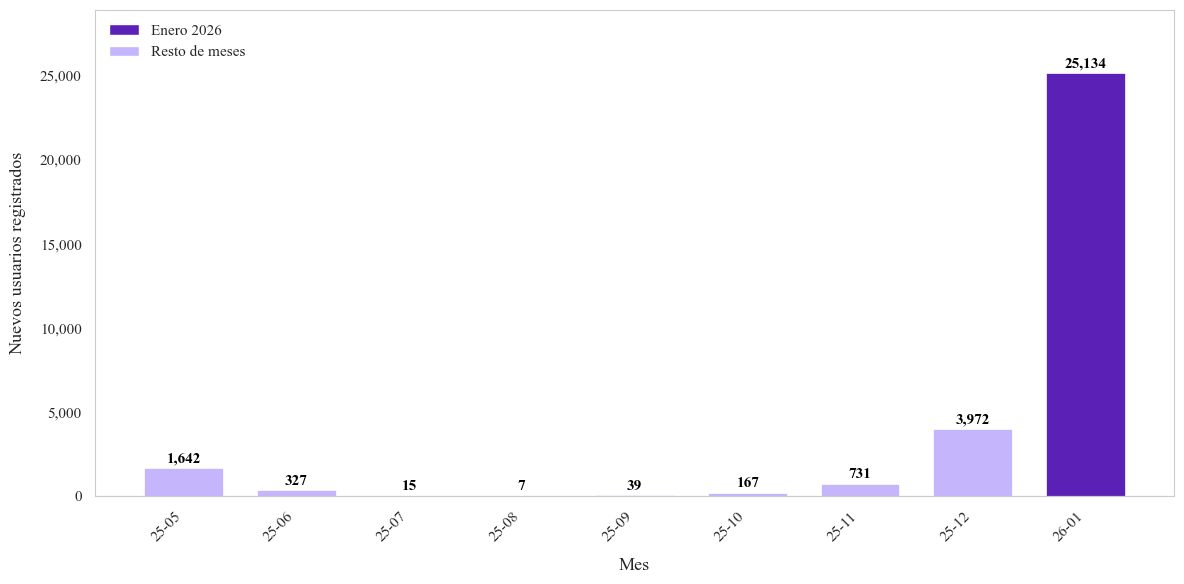

In [38]:
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 12,  # subido de 11 a 12
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,  # quitamos la cuadrícula
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

fig, ax = plt.subplots(figsize=(12, 6))

colores = ['#5B21B6' if str(mes) == '2026-01' else '#C4B5FD'
           for mes in registros_mes.index]

bars = ax.bar(
    range(len(registros_mes)),
    registros_mes.values,
    color=colores,
    edgecolor='white',
    linewidth=0.5,
    width=0.7
)

# Etiquetas más grandes
for bar, valor in zip(bars, registros_mes.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 150,
        f'{valor:,}',
        ha='center', va='bottom',
        fontsize=11,
        fontfamily='Times New Roman',
        color='black',  # negro puro
        fontweight='bold'  # negrita para que resalten más
    )

etiquetas = [str(mes)[2:] for mes in registros_mes.index]
ax.set_xticks(range(len(registros_mes)))
ax.set_xticklabels(etiquetas, rotation=45, ha='right', fontsize=11)

ax.set_xlabel('Mes', fontsize=13, labelpad=10)
ax.set_ylabel('Nuevos usuarios registrados', fontsize=13, labelpad=10)
ax.tick_params(axis='both', labelsize=11)  # añade esta línea
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, max(registros_mes.values) * 1.15)

# Línea horizontal en y=0 para dar referencia visual
ax.axhline(y=0, color='#cccccc', linewidth=0.8)

leyenda = [
    Patch(facecolor='#5B21B6', label='Enero 2026'),
    Patch(facecolor='#C4B5FD', label='Resto de meses')
]
ax.legend(handles=leyenda, fontsize=11, framealpha=0)

for spine in ['left', 'bottom', 'top', 'right']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('#cccccc')
    ax.spines[spine].set_linewidth(0.8)
    
plt.tight_layout()
plt.savefig('../outputs/G1_evolucion_registros.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='white')
plt.show()

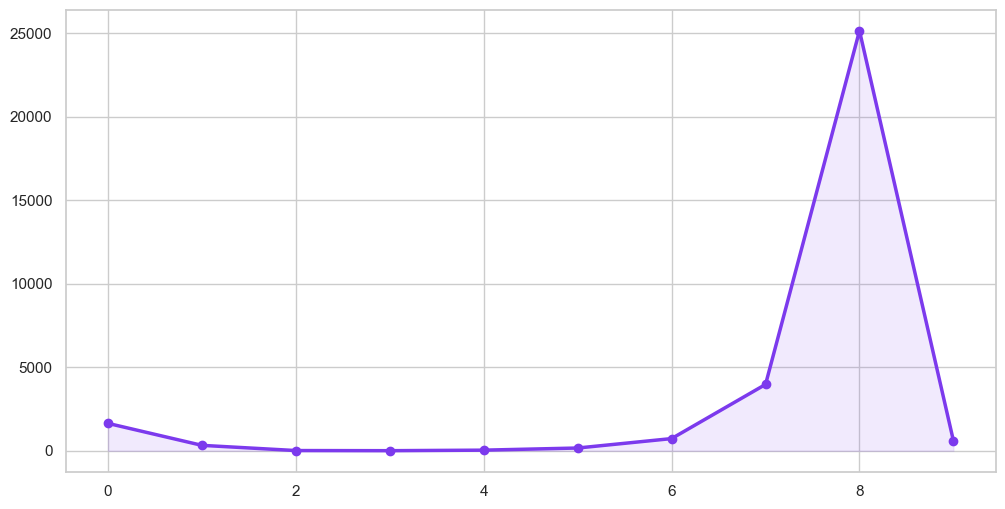

In [32]:
# Versión líneas para comparar
fig2, ax2 = plt.subplots(figsize=(12, 6))
ax2.plot(range(len(registros_mes)), registros_mes.values, 
         color='#7C3AED', linewidth=2.5, marker='o', markersize=6)
ax2.fill_between(range(len(registros_mes)), registros_mes.values, 
                 alpha=0.1, color='#7C3AED')

In [39]:
# ============================================
# ESTADÍSTICAS BASE PARA 5.1.3
# ============================================

# Usuarios de enero
enero = users[users['created_at'].dt.to_period('M') == '2026-01']

print("=== DISTRIBUCIÓN XP USUARIOS ENERO ===")
total_enero = len(enero)
sin_actividad = (enero['xp'] == 0).sum()
uso_minimo = ((enero['xp'] > 0) & (enero['xp'] <= 100)).sum()
uso_moderado = ((enero['xp'] > 100) & (enero['xp'] <= 500)).sum()
uso_alto = ((enero['xp'] > 500) & (enero['xp'] <= 2000)).sum()
heavy = (enero['xp'] > 2000).sum()

print(f"Sin actividad (XP=0): {sin_actividad/total_enero*100:.1f}%")
print(f"Uso mínimo (1-100): {uso_minimo/total_enero*100:.1f}%")
print(f"Uso moderado (101-500): {uso_moderado/total_enero*100:.1f}%")
print(f"Uso alto (501-2000): {uso_alto/total_enero*100:.1f}%")
print(f"Heavy user (>2000): {heavy/total_enero*100:.1f}%")

print("\n=== ESTADÍSTICAS DESCRIPTIVAS XP ENERO ===")
print(enero['xp'].describe().round(1))
print(f"CV: {enero['xp'].std()/enero['xp'].mean()*100:.1f}%")
print(f"Asimetría: {enero['xp'].skew():.2f}")
print(f"IQR: {enero['xp'].quantile(0.75) - enero['xp'].quantile(0.25):.1f}")

print("\n=== XP MEDIO POR PLAN ===")
print(users.groupby('subscription_type')['xp'].agg(['mean', 'median']).round(1))

=== DISTRIBUCIÓN XP USUARIOS ENERO ===
Sin actividad (XP=0): 1.6%
Uso mínimo (1-100): 51.7%
Uso moderado (101-500): 26.2%
Uso alto (501-2000): 18.7%
Heavy user (>2000): 1.7%

=== ESTADÍSTICAS DESCRIPTIVAS XP ENERO ===
count   25134.00
mean      321.20
std       614.60
min         0.00
25%         5.00
50%        89.00
75%       366.00
max     18627.00
Name: xp, dtype: float64
CV: 191.3%
Asimetría: 7.18
IQR: 361.0

=== XP MEDIO POR PLAN ===
                     mean  median
subscription_type                
free               569.00   55.00
magia             1915.20 1217.00
supermagia        2789.70 1047.00


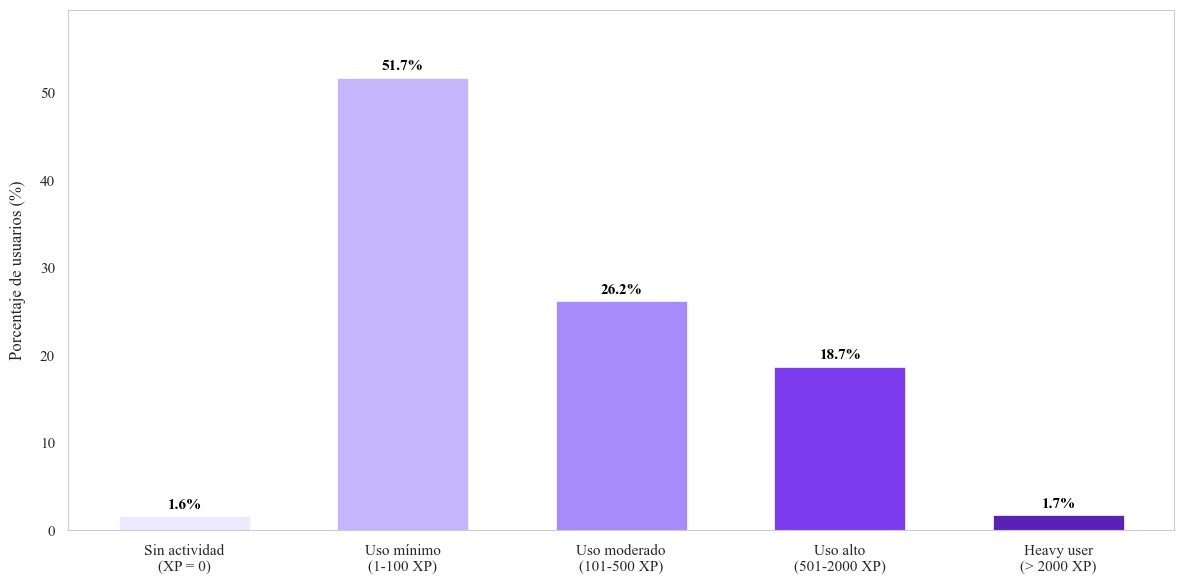

✅ G2 guardado en outputs/


In [40]:
# G2 - Distribución de engagement usuarios enero 2026
categorias = ['Sin actividad\n(XP = 0)', 'Uso mínimo\n(1-100 XP)', 
              'Uso moderado\n(101-500 XP)', 'Uso alto\n(501-2000 XP)', 
              'Heavy user\n(> 2000 XP)']
valores = [1.6, 51.7, 26.2, 18.7, 1.7]
colores = ['#EDE9FE', '#C4B5FD', '#A78BFA', '#7C3AED', '#5B21B6']

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    range(len(categorias)),
    valores,
    color=colores,
    edgecolor='white',
    linewidth=0.5,
    width=0.6
)

# Etiquetas encima de cada barra
for bar, valor in zip(bars, valores):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{valor}%',
        ha='center', va='bottom',
        fontsize=11,
        fontfamily='Times New Roman',
        color='black',
        fontweight='bold'
    )

ax.set_xticks(range(len(categorias)))
ax.set_xticklabels(categorias, fontsize=11)
ax.set_ylabel('Porcentaje de usuarios (%)', fontsize=12, labelpad=10)
ax.set_ylim(0, max(valores) * 1.15)
ax.tick_params(axis='y', labelsize=11)

# Recuadro
for spine in ['left', 'bottom', 'top', 'right']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('#cccccc')
    ax.spines[spine].set_linewidth(0.8)

plt.tight_layout()
plt.savefig('../outputs/G2_engagement_enero.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ G2 guardado en outputs/")

## Resumen metodológico del notebook

**Objetivo del notebook:**  
Realizar una exploración descriptiva inicial de la base de datos de PROXUS con el fin de establecer la foto general del caso de estudio: tamaño de la base de usuarios, distribución por perfil, distribución por plan, primera aproximación a conversión, ingresos acumulados, costes trazados de IA y evolución temporal de registros. Este notebook funciona como punto de partida contextual para el resto del análisis, no como análisis inferencial ni como modelización.

**Población o muestra analizada:**  
La población principal analizada está formada por 32.636 usuarios activos registrados en `users.csv` a fecha de corte 7 de febrero de 2026. Dentro de esta población se identifican 32.017 usuarios gratuitos puros, 516 pagadores activos y 103 usuarios churned, definidos como usuarios con `stripe_customer_id` pero con `subscription_type = free` en la fecha de corte. También se analizan 619 usuarios con relación histórica con Stripe, correspondientes a usuarios que han tenido algún vínculo de pago o suscripción.

**Periodo temporal utilizado:**  
El notebook combina fuentes con ventanas temporales distintas. La base de usuarios y las sesiones de test cubren aproximadamente el periodo comprendido entre mayo de 2025 y el 7 de febrero de 2026. En cambio, las fuentes económicas y de costes de IA tienen una cobertura más reducida: las suscripciones de Stripe comienzan el 29 de octubre de 2025 y los registros de `ai_spans` comienzan el 14 de octubre de 2025. Por tanto, los resultados de usuarios deben interpretarse como una foto acumulada de la base, mientras que los ingresos y costes de IA corresponden únicamente al periodo para el que existe trazabilidad disponible.

**Tablas de origen utilizadas:**  
- `users.csv`: tabla principal de usuarios, perfil, gamificación y estado de suscripción.
- `stripe_subscriptions.csv`: información de suscripciones, estado y planes contratados.
- `stripe_charges.csv`: cobros reales realizados mediante Stripe.
- `test_sessions.csv`: sesiones de realización de tests.
- `ai_spans.csv`: llamadas individuales a modelos de IA y coste asociado.
- `traces.csv`: trazas que permiten vincular llamadas de IA con usuarios y funcionalidades.

**Variables y métricas generadas:**  
- Número total de usuarios.
- Distribución por `subscription_type`.
- Distribución por tipo de usuario (`type`).
- Distribución por género, incluyendo una agrupación de categorías minoritarias.
- Usuarios con `stripe_customer_id`.
- Usuarios actualmente de pago.
- Usuarios churned: usuarios con Stripe pero actualmente en plan free.
- Tasa de conversión actual: pagadores activos / usuarios totales.
- Ingresos acumulados a partir de cobros exitosos de Stripe.
- Cobros fallidos.
- Coste total de IA a partir de `ai_spans.cost`.
- Coste de IA por funcionalidad a partir del cruce entre `traces` y `ai_spans`.
- Distribución mensual de registros.
- Segmentación descriptiva de engagement de usuarios registrados en enero de 2026 mediante XP:
  - XP = 0.
  - XP 1-100.
  - XP 101-500.
  - XP 501-2000.
  - XP > 2000.

**Resultados principales:**  
- La base contiene 32.636 usuarios activos.
- 32.017 usuarios son free puros, 516 son pagadores activos y 103 son churned.
- 619 usuarios tienen `stripe_customer_id`, por lo que han tenido algún tipo de relación con Stripe.
- La tasa de conversión actual calculada sobre pagadores activos es del 1,58%.
- La tasa de usuarios con Stripe sobre el total es aproximadamente del 1,90%.
- La distribución por plan actual muestra 32.120 usuarios en free, 399 en MagIA y 117 en SuperMagIA.
- El perfil de usuario es mayoritariamente universitario.
- Enero de 2026 concentra 25.134 nuevos registros, lo que representa el principal pico de crecimiento de la base.
- Dentro de los usuarios registrados en enero, el 51,7% presenta un uso mínimo según XP acumulada entre 1 y 100.
- Los usuarios de pago presentan un XP medio claramente superior al de los usuarios gratuitos, lo que sugiere una asociación descriptiva entre mayor engagement y pago.
- Los ingresos cobrados correctamente en Stripe ascienden a 5.010,84 euros.
- El coste total trazado de IA asciende a 578,77 dólares en el periodo disponible.
- Las funcionalidades con mayor coste trazado de IA son principalmente la generación de tests desde apuntes, la generación de flashcards y el chat.

**Figuras o tablas que alimentan el TFG:**  
- Gráfico de evolución mensual de registros (`G1_evolucion_registros.png`), útil para contextualizar el crecimiento de PROXUS y justificar la relevancia de enero de 2026.
- Gráfico de distribución de engagement de usuarios registrados en enero (`G2_engagement_enero.png`), útil para mostrar la heterogeneidad del uso dentro de la gran cohorte de crecimiento.
- Tabla descriptiva de distribución por género, tipo de usuario, plan y conversión, útil para la sección inicial de resultados descriptivos.
- Tabla de rangos temporales por fuente, útil para la sección metodológica.
- Tabla de ingresos y costes acumulados, útil como primera aproximación al análisis económico, aunque deberá complementarse y matizarse en notebooks posteriores.

**Relación con otros notebooks:**  
Este notebook proporciona el contexto general y las cifras base que deben mantenerse coherentes en los análisis posteriores. El Notebook 02 deberá profundizar en la conversión y distinguir conversores inmediatos y tardíos. El Notebook 03 deberá analizar límites de uso, fricción freemium y ProxusCoins. El Notebook 04 deberá aportar el análisis inferencial o de modelización que complemente el análisis descriptivo. Las cifras de usuarios totales, pagadores activos, churned y usuarios con Stripe deben mantenerse como referencia común en toda la pipeline.

**Limitaciones metodológicas:**  
- El notebook es descriptivo y no permite establecer causalidad.
- Las fuentes utilizadas no comparten exactamente el mismo periodo temporal.
- El análisis de costes de IA solo cubre el periodo con trazabilidad disponible en `traces` y `ai_spans`.
- La variable XP se utiliza como proxy de engagement, pero no captura por sí sola todas las dimensiones del uso real.
- La categoría “free” en `subscription_type` no equivale a “free puro”, ya que incluye también usuarios churned.
- El desglose de costes por `model_mask` debe revisarse, ya que el coste total de IA es muy superior a la suma de los costes clasificados como MagIA y SuperMagIA.
- El dato de churn en enero debe interpretarse como usuarios registrados en enero con Stripe que figuran como free en la fecha de corte, no necesariamente como una cancelación observada directamente dentro del mes.

**Conclusión operativa para el TFG:**  
Este notebook debe mantenerse como bloque descriptivo inicial y contextual. Sus resultados principales son válidos para introducir el caso, describir la base de usuarios, justificar la importancia de enero de 2026 y presentar una primera aproximación a monetización y costes de IA. No debe utilizarse como evidencia inferencial ni como análisis definitivo de conversión, retención o fricción. Las cifras base de usuarios, pagadores, churned y usuarios con Stripe deben considerarse definitivas salvo que notebooks posteriores utilicen muestras explícitamente filtradas y documentadas.